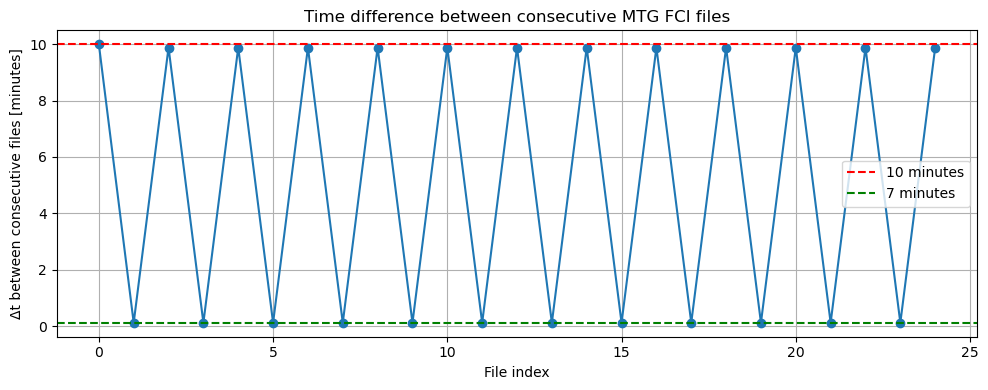

In [6]:
from pathlib import Path
import re
from datetime import datetime
import matplotlib.pyplot as plt

def extract_start_time(filename: str) -> datetime:
    """
    Extracts the start datetime from an MTG FCI filename.
    """
    match = re.search(r'OPE_(\d{14})_\d{14}', filename)
    if not match:
        raise ValueError(f"Could not parse start time from {filename}")
    return datetime.strptime(match.group(1), "%Y%m%d%H%M%S")

data_dir = Path("/Users/luciereymondet/GitHub/GOFLOW_LR/data/raw")

files_with_time = []
for f in data_dir.iterdir():
    if f.is_file():
        try:
            start_time = extract_start_time(f.name)
            files_with_time.append((start_time, f))
        except ValueError:
            pass  # skip files that don't match the pattern

# Sort by start time
files_with_time.sort(key=lambda x: x[0])

start_times = [t for t, _ in files_with_time]

time_deltas_minutes = [
    (start_times[i+1] - start_times[i]).total_seconds() / 60
    for i in range(len(start_times) - 1)
]

plt.figure(figsize=(10, 4))
plt.plot(time_deltas_minutes, marker="o", linestyle="-")
plt.axhline(10, color="red", linestyle="--", label="10 minutes")
plt.axhline(7/60, color="green", linestyle="--", label="7 minutes")

plt.xlabel("File index")
plt.ylabel("Δt between consecutive files [minutes]")
plt.title("Time difference between consecutive MTG FCI files")
plt.legend()
plt.grid(True)
# plt.ylim(0,1)
plt.tight_layout()
plt.show()


/var/folders/2w/tdn42d6s2lx6l_8md1rzw46r0000gn/T/ipykernel_8400/1627859527.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


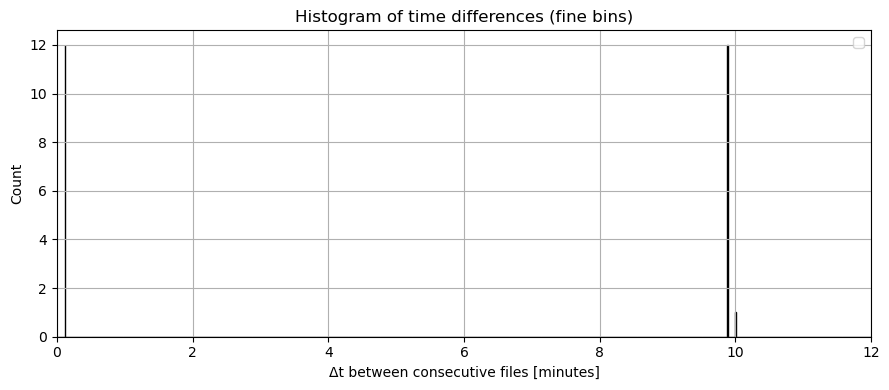

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Convert 7 seconds to minutes
seven_sec = 7 / 60  # ≈ 0.1167 min

bins = np.concatenate([
    # very small deltas (seconds-scale)
    np.linspace(0, 0.5, 50),

    # around ~7 seconds
    np.linspace(seven_sec - 0.02, seven_sec + 0.02, 40),

    # medium gaps
    np.linspace(0.5, 9.5, 20),

    # very tight around 10 minutes
    np.linspace(9.8, 10.2, 100),

    # larger gaps
    np.linspace(10.2, 30, 30),
])

bins = np.unique(bins)

plt.figure(figsize=(9, 4))

plt.hist(
    time_deltas_minutes,
    bins=bins,
    edgecolor="black"
)


plt.xlabel("Δt between consecutive files [minutes]")
plt.ylabel("Count")
plt.title("Histogram of time differences (fine bins)")
plt.legend()
plt.grid(True)
plt.xlim(0,12)
plt.tight_layout()
plt.show()
